In [35]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection 
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import pandas as pd
import re

In [46]:
df = pd.read_csv('../exports/intensive_search_with_index.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-monolith_app.1.nw1m8qvuhf9yxynoiesqzqdpj'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.2psgdvtnhtcce9zjn6nhcv2x8.k9479041ffyeqesp8vs5sg6ci'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.gkxfmk0f14ry4f8cex3726nm9.rwlqytmbrgtd88vbj9ztqn7i7'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.m7evt2fhzisw4dshpe9gae22s.84gyi26d4jcdiqh2p4d64chb1'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.r0dh5upwj4tebg66ket20fv8l.jl4l8drmn7y7zmmo6vdafuuld'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-monolith_gateway.1.jdak5l40elg0jaf8u9aa138x1'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.2psgdvtnhtcce9zjn6nhcv2x8.v8n6i75v955i3iaset6drgl37'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.gkxfmk0f14ry4f8cex3726nm9.pfmqrgrby7jo8wqg3apz6slqu'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.m7evt2fhzisw4dshpe9gae22s.8z97msl5oj5sm96cvuy4hrlmr'},...,mem_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.2psgdvtnhtcce9zjn6nhcv2x8.v8n6i75v955i3iaset6drgl37'},mem_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.gkxfmk0f14ry4f8cex3726nm9.pfmqrgrby7jo8wqg3apz6slqu'},mem_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.m7evt2fhzisw4dshpe9gae22s.8z97msl5oj5sm96cvuy4hrlmr'},mem_by_svc__series_9 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.r0dh5upwj4tebg66ket20fv8l.wdvv36ohoivqv22x6c5evyxpz'},mem_by_svc__series_10 {'container_label_com_docker_swarm_task_name': 'chat-monolith_postgres-exporter.1.tsreukaccmn7gw3tln3yqd1qt'},mem_by_svc__series_11 {'container_label_com_docker_swarm_task_name': 'chat-monolith_postgres.1.l3b5riyuy40rj2xpko8rv4c4x'},mem_by_svc__series_12 {'container_label_com_docker_swarm_task_name': 'chat-monolith_prometheus.1.er28mmdv9b1kcdn0jo3q530jo'},k6_users__series_0 {},http_rt_latency__series_0 {},"pg_database_size_chat_monolith__pg_database_size_bytes {'datname': 'chat_monolith', 'instance': '10.0.1.12:9187', 'job': 'chat-monolith-postgres'}"
0,2026-05-06 06:26:37.599999905+00:00,0.047685,0.028289,0.021313,0.028657,0.027776,0.010918,0.003622,0.001990,0.003127,...,9535488.0,9498624.0,9539584.0,9666560.0,8507392.0,151912448.0,86949888.0,1.0,0.028840,94131891.0
1,2026-05-06 06:26:42.599999905+00:00,0.047685,0.026863,0.021313,0.028990,0.027776,0.010918,0.003612,0.001233,0.003702,...,9535488.0,9498624.0,9543680.0,9662464.0,8507392.0,151912448.0,86949888.0,1.0,0.028788,94131891.0
2,2026-05-06 06:26:47.599999905+00:00,0.050561,0.026749,0.022494,0.028990,0.027084,0.011083,0.003663,0.001844,0.003702,...,9535488.0,9449472.0,9543680.0,9662464.0,8507392.0,151990272.0,89186304.0,1.0,0.028716,94131891.0
3,2026-05-06 06:26:52.599999905+00:00,0.050561,0.028241,0.022494,0.030789,0.027084,0.011083,0.003376,0.001591,0.003626,...,9535488.0,9449472.0,9596928.0,9662464.0,8507392.0,151990272.0,89186304.0,1.0,0.028629,94131891.0
4,2026-05-06 06:26:57.599999905+00:00,0.048047,0.028241,0.023143,0.030789,0.026571,0.010822,0.003195,0.001583,0.003626,...,9535488.0,9449472.0,9596928.0,9662464.0,8507392.0,151912448.0,89202688.0,1.0,0.028575,94131891.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,2026-05-06 07:06:17.599999905+00:00,0.003333,0.027418,0.024467,0.029299,0.029838,0.000000,0.003041,0.002299,0.003395,...,9486336.0,9883648.0,9502720.0,9674752.0,9269248.0,167600128.0,97042432.0,1.0,1.159730,94443187.0
477,2026-05-06 07:06:22.599999905+00:00,0.003333,0.024622,0.024467,0.030017,0.029838,0.000000,0.003161,0.002299,0.00

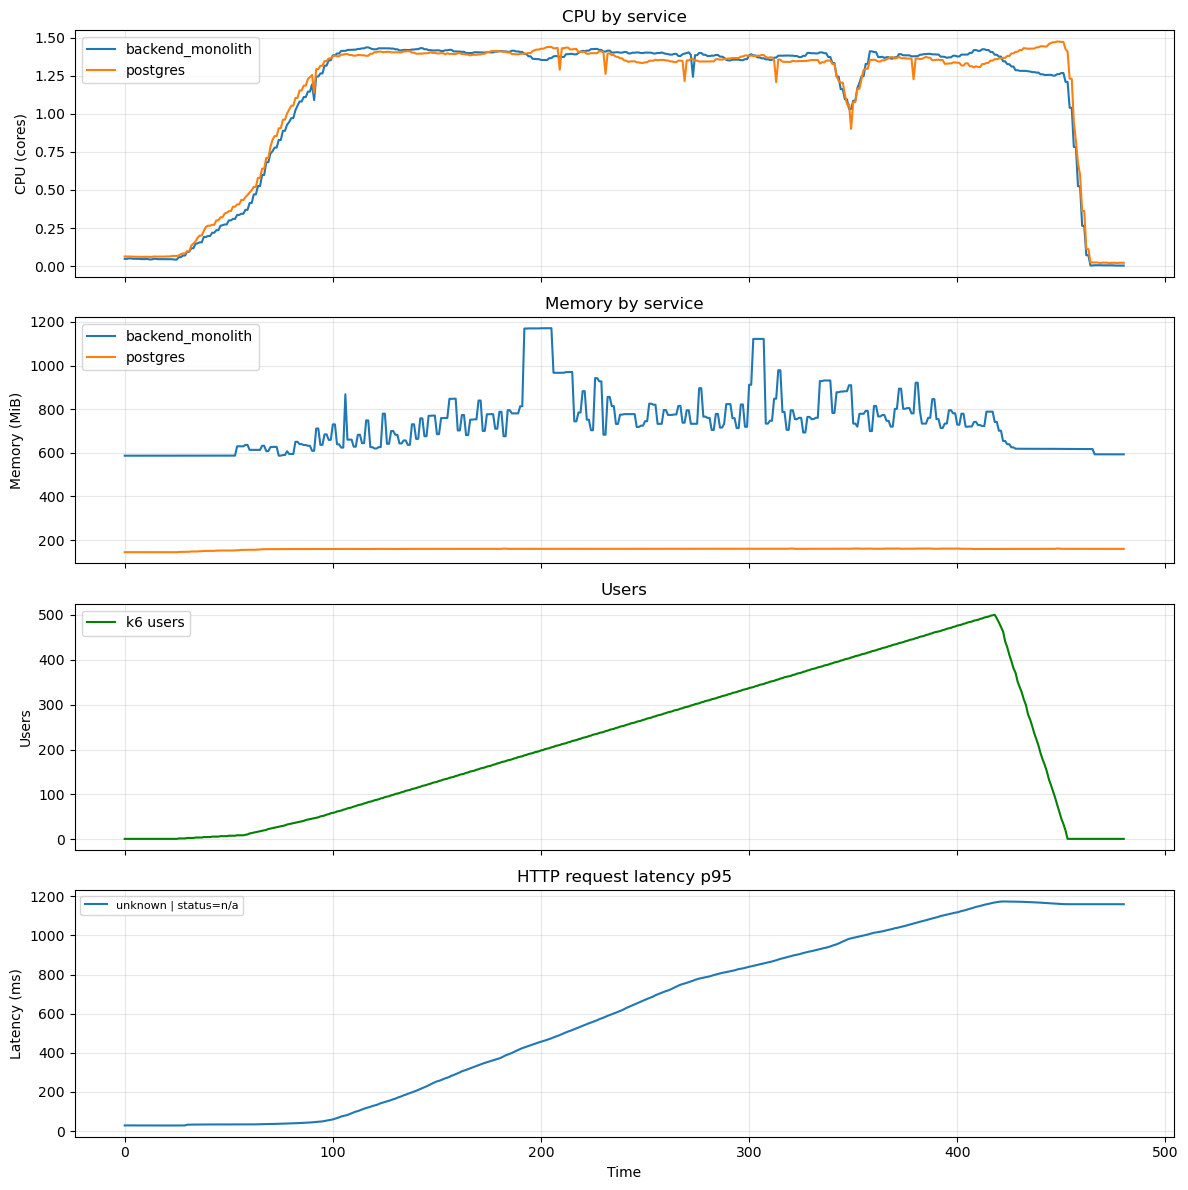

In [47]:
# --- helper: find column containing metric prefix + service name ---
def col_for(metric_prefix: str, service_substring: str) -> str:
    matches = [c for c in df.columns if c.startswith(metric_prefix) and service_substring in c]
    if not matches:
        raise ValueError(f"No column found for prefix='{metric_prefix}' and service='{service_substring}'")
    return matches[0]

services = {
    # "search-service": "search-service",
    # "elasticsearch": "elasticsearch",
    # "user-service": "user-service",
    "backend_monolith": "app",
    "postgres": "postgres.1",
}

cpu_cols = {label: col_for("cpu_by_svc__", needle) for label, needle in services.items()}
mem_cols = {label: col_for("mem_by_svc__", needle) for label, needle in services.items()}


# memory in MiB for readability
mem_mib = {label: df[col] / (1024 * 1024) for label, col in mem_cols.items()}

# optional graph: k6 users
k6_users_col = next((c for c in df.columns if c.startswith("k6_users__")), None)

# HTTP latency p95 columns for GET methods only
http_get_latency_cols = [
    c for c in df.columns
    if c.startswith("http_rt_latency__")
]

# nicer label for HTTP latency legend
def latency_label(col: str) -> str:
    name_match = re.search(r"'name': '([^']+)'", col)
    status_match = re.search(r"'status': '([^']+)'", col)
    error_match = re.search(r"'error': '([^']+)'", col)

    name = name_match.group(1) if name_match else "unknown"
    status = status_match.group(1) if status_match else "n/a"

    if error_match:
        return f"{name} | err={error_match.group(1)} | status={status}"
    return f"{name} | status={status}"

# --- plot ---
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(12, 12))

# 1) CPU
for label, col in cpu_cols.items():
    axes[0].plot(df.index, df[col], label=label)
axes[0].set_title("CPU by service")
axes[0].set_ylabel("CPU (cores)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

# 2) Memory
for label, series in mem_mib.items():
    axes[1].plot(df.index, series, label=label)
axes[1].set_title("Memory by service")
axes[1].set_ylabel("Memory (MiB)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")

# 3) k6 users (optional)
if k6_users_col is not None:
    axes[2].plot(df.index, df[k6_users_col], color="green", label="k6 users")
    axes[2].legend(loc="upper left")
axes[2].set_title("Users")
axes[2].set_ylabel("Users")
axes[2].grid(True, alpha=0.3)

# 4) HTTP latency p95 (GET only)
# todo the http get latency is only one value, calculate when it crosses the 1000ms 
if http_get_latency_cols:
    for col in http_get_latency_cols:
        axes[3].plot(df.index, df[col] * 1000, label=latency_label(col))
    axes[3].legend(loc="upper left", fontsize=8)
else:
    axes[3].text(0.5, 0.5, "No GET latency columns found", ha="center", va="center", transform=axes[3].transAxes)

axes[3].set_title("HTTP request latency p95")
axes[3].set_ylabel("Latency (ms)")
axes[3].set_xlabel("Time")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
# Updated plotting block: includes optional Elasticsearch CPU in top chart
work_df = df.copy()
work_df["timestamp"] = pd.to_datetime(work_df["timestamp"], utc=True)
work_df = work_df.set_index("timestamp").sort_index()


def sum_service(prefix: str, service_token: str) -> pd.Series:
    cols = [c for c in work_df.columns if c.startswith(prefix) and service_token in c]
    if not cols:
        return pd.Series(index=work_df.index, data=0.0)
    return work_df[cols].fillna(0.0).sum(axis=1)


# CPU attribution built from container-level CSV metrics
s_pg = sum_service("cpu_by_svc__", "chat-eda_postgres.1") + sum_service("cpu_by_svc__", "chat-monolith_postgres.1")
user_service = sum_service("cpu_by_svc__", "chat-eda_user-service")
search_service = sum_service("cpu_by_svc__", "chat-eda_search-service")
s_app = (
    sum_service("cpu_by_svc__", "chat-eda_user-service")
    + sum_service("cpu_by_svc__", "chat-eda_search-service")
    + sum_service("cpu_by_svc__", "chat-eda_gateway")
    + sum_service("cpu_by_svc__", "chat-eda_ws-service")
    + sum_service("cpu_by_svc__", "app")
)

has_es = any(
    c.startswith("cpu_by_svc__")
    and (
        "chat-eda_elasticsearch.1" in c
        or "chat-monolith_elasticsearch.1" in c
    )
    for c in work_df.columns
)
s_es = (
    sum_service("cpu_by_svc__", "chat-eda_elasticsearch.1")
    + sum_service("cpu_by_svc__", "chat-monolith_elasticsearch.1")
)

s_vm = work_df[[c for c in work_df.columns if c.startswith("cpu_by_svc__")]].fillna(0.0).sum(axis=1)

cpu_parts = [
    s_vm.rename("vm"),
    s_pg.rename("postgres"),
    s_app.rename("app"),
    user_service.rename("user_service"),
    search_service.rename("search_service")
]
if has_es:
    cpu_parts.insert(2, s_es.rename("elasticsearch"))

cpu_df = pd.concat(cpu_parts, axis=1).interpolate(limit_direction="both")

# k6 users and HTTP p95 built from CSV columns
k6_users_cols = [c for c in work_df.columns if c.startswith("k6_users__")]
k6_users = work_df[k6_users_cols].fillna(0.0).sum(axis=1) if k6_users_cols else pd.Series(dtype=float)

lat_cols = [
    c
    for c in work_df.columns
    if c.startswith("http_rt_latency__")
]
http_rt_latency = work_df[lat_cols].mean(axis=1, skipna=True) if lat_cols else pd.Series(dtype=float)

# ---- 3 rows: CPU (top), HTTP latency (middle), k6 users (bottom) ----
fig, (ax_cpu, ax_lat, ax_k6) = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 1, 0.8]}
)

# ========== TOP: CPU attribution ==========
if "elasticsearch" in cpu_df.columns:
    ax_cpu.stackplot(
        cpu_df.index,
        cpu_df["postgres"],
        cpu_df["elasticsearch"],
        # cpu_df["app"],
        cpu_df["user_service"],
        cpu_df["search_service"],
        # labels=["Postgres (cores)", "Elasticsearch (cores)", "App (cores)"],
        labels=["Postgres (cores)", "Elasticsearch (cores)", "User service (cores)", "Search service (cores)"],
        # colors=["blue", "green", "orange"],
        colors = ["#2563EB", "#16A34A", "#F59E0B", "#EF4444", "#7C3AED"],
        alpha=0.55,
    )
else:
    ax_cpu.stackplot(
        cpu_df.index,
        cpu_df["postgres"],
        cpu_df["app"],
        labels=["Postgres (cores)", "App (cores)"],
        colors = ["#2563EB", "#16A34A", "#F59E0B", "#EF4444", "#7C3AED"],
        alpha=0.55,
    )

ax_cpu.plot(cpu_df.index, cpu_df["vm"], lw=1.8, label="Total tracked container CPU (cores)")

ax_cpu.set_title("CPU by service")
ax_cpu.set_ylabel("CPU (cores)")
ax_cpu.grid(True, alpha=0.25)
ax_cpu.legend(loc="upper left")

# ========== MIDDLE: HTTP latency ==========
cross_ts = None
cross_val_ms = None

if not http_rt_latency.empty and not http_rt_latency.isna().all():
    s = http_rt_latency.ffill().bfill() * 1000  # seconds -> ms
    ax_lat.step(
        s.index, s.values, where="post",
        color="tab:red", linewidth=1.4,
        label="HTTP request duration p95"
    )

    crossed = s[s > 1000]
    if not crossed.empty:
        cross_ts = crossed.index[0]
        cross_val_ms = float(crossed.iloc[0])
else:
    ax_lat.text(
        0.5, 0.5, "No data in http_rt_latency",
        ha="center", va="center", transform=ax_lat.transAxes
    )

ax_lat.axhline(
    1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7,
    label="latency limit 1000ms"
)
ax_lat.set_title("HTTP latency p95")
ax_lat.set_ylabel("Latency (ms)")
ax_lat.grid(True, alpha=0.3)

# ========== BOTTOM: k6 users ==========
if not k6_users.empty:
    s_u = k6_users
    ax_k6.step(
        s_u.index, s_u.values, where="post",
        color="tab:cyan", lw=1.6, linestyle="--", label="Users"
    )
else:
    ax_k6.text(
        0.5, 0.5, "No data in k6_users",
        ha="center", va="center", transform=ax_k6.transAxes
    )

ax_k6.set_title("Users")
ax_k6.set_xlabel("Time (UTC)")
ax_k6.set_ylabel("Users")
ax_k6.grid(True, alpha=0.3)

# ========== Vertical marker on all subplots ==========
if cross_ts is not None:
    for ax in (ax_cpu, ax_lat, ax_k6):
        ax.axvline(cross_ts, color="magenta", linestyle="--", linewidth=1.2, alpha=0.9)

    if not k6_users.empty:
        s_u = k6_users
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        ax_lat.annotate(
            f">1000ms at {users_at_cross:.0f} VUs",
            xy=(cross_ts, cross_val_ms),
            xytext=(8, 8),
            textcoords="offset points",
            color="magenta",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="magenta",
                lw=1,
                alpha=0.9
            )
        )

ax_lat.legend(loc="upper left")
ax_k6.legend(loc="upper left")

plt.tight_layout()
plt.show()

if cross_ts is None:
    print("HTTP p95 never exceeded 1000 ms in selected range.")
else:
    print(f"First HTTP p95 > 1000 ms at: {cross_ts}")
    print(f"Latency at crossing: {cross_val_ms:.2f} ms")

    if not k6_users.empty:
        s_u = k6_users
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        print(f"k6 users near crossing: {users_at_cross:.0f}")

NameError: name 'df' is not defined